In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DATA_DIR = "data/raw"
print('Done')

Done


1. Order Table

In [2]:
df_orders = pd.read_csv(os.path.join(RAW_DATA_DIR, "olist_orders_dataset.csv"))
print("=== 1. OVERVIEW OF ORDER TABLE ===")
print(f"Total number of recorded orders: {df_orders.shape[0]:,}")
print("\nOrder status (order_status):")
print(df_orders['order_status'].value_counts())

print("\n⚠️ Number of null values in orders:")
print(df_orders.isnull().sum())

print("\nNumber of canceled orders with a null delivery date:")
print(df_orders[df_orders['order_status'] == 'canceled']['order_delivered_customer_date'].isnull().sum())

=== 1. OVERVIEW OF ORDER TABLE ===
Total number of recorded orders: 99,441

Order status (order_status):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

⚠️ Number of null values in orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Number of canceled orders with a null delivery date:
619


2. Order Detail

In [3]:
df_items = pd.read_csv(os.path.join(RAW_DATA_DIR, "olist_order_items_dataset.csv"))
print("=== 2. CHECKING ORDER VALUES ===")
print(df_items[['price', 'freight_value']].describe())
print("\nTop 5 orders with the most items in a single transaction:")
print(df_items['order_id'].value_counts().head())

=== 2. CHECKING ORDER VALUES ===
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Top 5 orders with the most items in a single transaction:
order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
Name: count, dtype: int64


3. Order Payment

In [4]:
df_payments = pd.read_csv(os.path.join(RAW_DATA_DIR, "olist_order_payments_dataset.csv"))
print("=== 3. PAYMENT METHOD ===")
print(df_payments['payment_type'].value_counts())
print('Top 5 payment methods by order volume:')
print(df_payments['order_id'].value_counts().head())

=== 3. PAYMENT METHOD ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64
Top 5 payment methods by order volume:
order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
Name: count, dtype: int64


4. Customer & Billing

In [5]:
df_customers = pd.read_csv(os.path.join(RAW_DATA_DIR, "olist_customers_dataset.csv"))
df_products = pd.read_csv(os.path.join(RAW_DATA_DIR, "olist_products_dataset.csv"))
df_translation = pd.read_csv(os.path.join(RAW_DATA_DIR, "product_category_name_translation.csv"))

print("=== 4. CUSTOMER & PRODUCT ===")
print(f"Number of customer_id (product id): {df_customers['customer_id'].nunique():,}")
print(f"Number of customer_unique_id (real user): {df_customers['customer_unique_id'].nunique():,}")

missing_categories = set(df_products['product_category_name'].dropna()) - set(df_translation['product_category_name'])
print(f"\n⚠️ Number of product categories missing of English translation: {len(missing_categories)}")
print("Detailed list:", missing_categories)

=== 4. CUSTOMER & PRODUCT ===
Number of customer_id (product id): 99,441
Number of customer_unique_id (real user): 96,096

⚠️ Number of product categories missing of English translation: 2
Detailed list: {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}


5. Customer Distribution by Geography

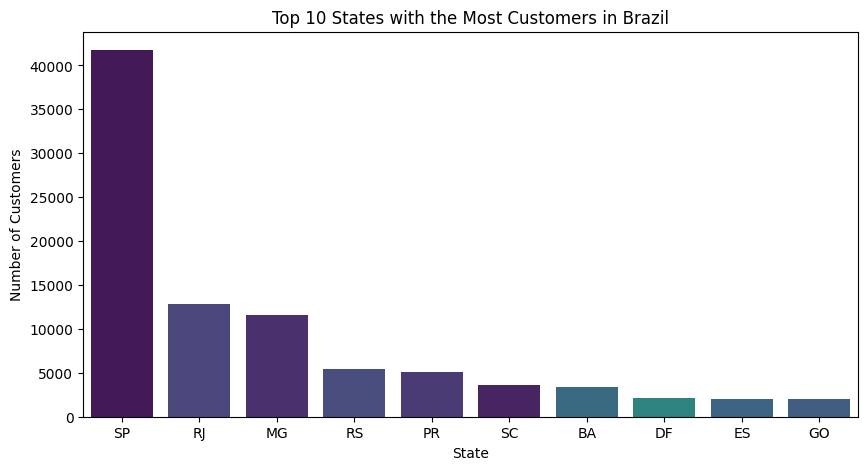

In [6]:
# Plot the top 10 states with the highest number of customers
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_customers, 
    x='customer_state', 
    order=df_customers['customer_state'].value_counts().index[:10], 
    hue='customer_state',  # Color mapping by state
    palette='viridis',
    legend=False           # Hide legend since state names are on the X-axis
)
plt.title('Top 10 States with the Most Customers in Brazil')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

In [13]:
import duckdb
import pandas as pd

db_path = "/Users/ciaranguyen/Documents/ecom_project/dev.duckdb"
con = duckdb.connect(db_path)

df_fact = con.execute("SELECT * FROM main.marts LIMIT 5").df()

print("🎉 PIPELINE RUN SUCCESSFUL! HERE IS THE CLEANED FACT_ORDERS TABLE:")
display(df_fact)

con.close()

🎉 PIPELINE RUN SUCCESSFUL! HERE IS THE CLEANED FACT_ORDERS TABLE:


,order_id,customer_id,order_status,purchase_at,product_category,total_item_price,total_shipping_cost,total_items_ordered,actual_delivery_days,days_delayed_vs_estimate,total_amount_paid
0,683481ae11f5f4ccfd9263a3bd7f25d4,38e26bdd2add60a638859e52ea718cf2,delivered,2018-06-21 11:12:14,drinks,119.80,30.98,2,7,-21,150.78
1,1d21d12aea4b6b1a7debf1e5e5604734,0120ff9de7b5aba7cd8676c093f189de,delivered,2018-01-25 15:50:30,sports_leisure,26.11,13.94,1,14,-25,40.05
2,ace0c35b85db51d5c8dd029487bb9f34,cd68b3fa4e48736451e77e7f9c6bd069,delivered,2018-01-25 11:19:00,telephony,26.99,7.78,1,4,-11,34.77
3,b7b6e52282e462db3a8fd56c2d27389c,f79872c7d7a7fbe7efcb6cbcd020de7e,delivered,2017-08-30 01:50:04,health_beauty,15.48,11.85,1,5,-14,27.33
4,29f6c8fd6605fb62cceeb59ce698bf75,9ecee7edd51fea4cc04b55c51d5dad04,delivered,2018-06-23 19:04:41,sports_leisure,59.90,17.35,1,5,-34,77.25
